# Capybara downstream analysis

This notebook analyzes the existing `synthetic_data_capybara_results.xlsx` workbook only. It does **not** rerun Capybara.

Outputs include the main distance boxplot, generated-versus-inferred frequency profiles, directional-bias and ambiguity figures, and summary/processing tables.

In [1]:
import sys
from pathlib import Path

# Locate the repository root so the notebook runs from any working directory
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "synthetic_datasets.py").exists())
sys.path.insert(0, str(REPO_ROOT))
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

INPUT_FILE = REPO_ROOT / "synthetic_data_capybara_results.xlsx"
OUTPUT_DIR = Path("capybara_downstream_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REGIME_TO_REGION = {"high_cosp": "R1", "low_switch": "R1", "high_switch": "R2", "medium": "R3"}
REGION_ORDER = ["R1", "R2", "R3"]
GENERATOR_ORDER = ["asymmetree", "coala", "cophylo", "treeducken"]
COST_ORDER = ["classical_1", "classical_3"]
COST_LABELS = {"classical_1": "<0,1,2,1>", "classical_3": "<0,1,3,1>"}
COST_COLORS = {"classical_1": "#4C78A8", "classical_3": "#F58518"}
GENERATOR_COLORS = {"asymmetree": "#0072B2", "coala": "#E69F00", "cophylo": "#009E73", "treeducken": "#CC79A7"}

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "axes.spines.top": False, "axes.spines.right": False})
print("Input:", INPUT_FILE.relative_to(REPO_ROOT))
print("Output directory:", OUTPUT_DIR)

Input: synthetic_data_capybara_results.xlsx
Output directory: capybara_downstream_outputs


## Load and prepare the completed results

In [2]:
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Missing input workbook: {INPUT_FILE}")

workbook = pd.ExcelFile(INPUT_FILE)
frames = []
for sheet_name in workbook.sheet_names:
    frame = pd.read_excel(INPUT_FILE, sheet_name=sheet_name)
    if frame.empty or not {"dataset_path", "generator", "regime"}.issubset(frame.columns):
        continue
    frame["source_sheet"] = sheet_name
    frames.append(frame)
if not frames:
    raise ValueError("No result sheets were found in the workbook")

results = pd.concat(frames, ignore_index=True)
results["generator"] = results["generator"].astype(str).str.lower()
results["regime"] = results["regime"].astype(str).str.lower()
results["region"] = results["regime"].map(REGIME_TO_REGION)
for column in ["real_cosp_freq", "real_switch_freq", "min_real_observed_distance", "event_vector_count", "task_elapsed_seconds"]:
    if column in results:
        results[column] = pd.to_numeric(results[column], errors="coerce")

closest_rx = re.compile(r"\[\s*([0-9.eE+\-]+)\s*,\s*([0-9.eE+\-]+)\s*\]")
def parse_closest(value):
    match = closest_rx.search(str(value))
    return (float(match.group(1)), float(match.group(2))) if match else (np.nan, np.nan)

closest = results.get("closest_observed_frequency", pd.Series(index=results.index, dtype=object)).apply(parse_closest)
results["inferred_cosp_freq"] = [value[0] for value in closest]
results["inferred_switch_freq"] = [value[1] for value in closest]
results["delta_cosp"] = results["inferred_cosp_freq"] - results["real_cosp_freq"]
results["delta_switch"] = results["inferred_switch_freq"] - results["real_switch_freq"]
results["capybara_status"] = results.get("capybara_status", "completed").fillna("completed").astype(str).str.lower()

classical = results[results["cost_label"].isin(COST_ORDER)].copy()
completed = classical[(classical["capybara_status"] == "completed") & classical["min_real_observed_distance"].notna()].copy()
print(f"Loaded {len(results):,} task rows from {len(frames)} result sheets")
print(f"Completed classical task rows available for figures: {len(completed):,}")
pd.crosstab(classical["generator"], [classical["region"], classical["capybara_status"]], dropna=False)

Loaded 24,470 task rows from 9 result sheets
Completed classical task rows available for figures: 17,055


region                 R1                R2                R3        
capybara_status completed skipped completed skipped completed skipped
generator                                                            
asymmetree           2000       0      1419     581      2000       0
coala                1998       0      1998       0      1998       0
treeducken           1980       0      1708       0      1954       2

## Figure 1 — distance between generating and parsimonious event frequencies

The y-axis is `min_real_observed_distance`. Each panel is a target region; the two boxes within each generator correspond to the two classical cost vectors.

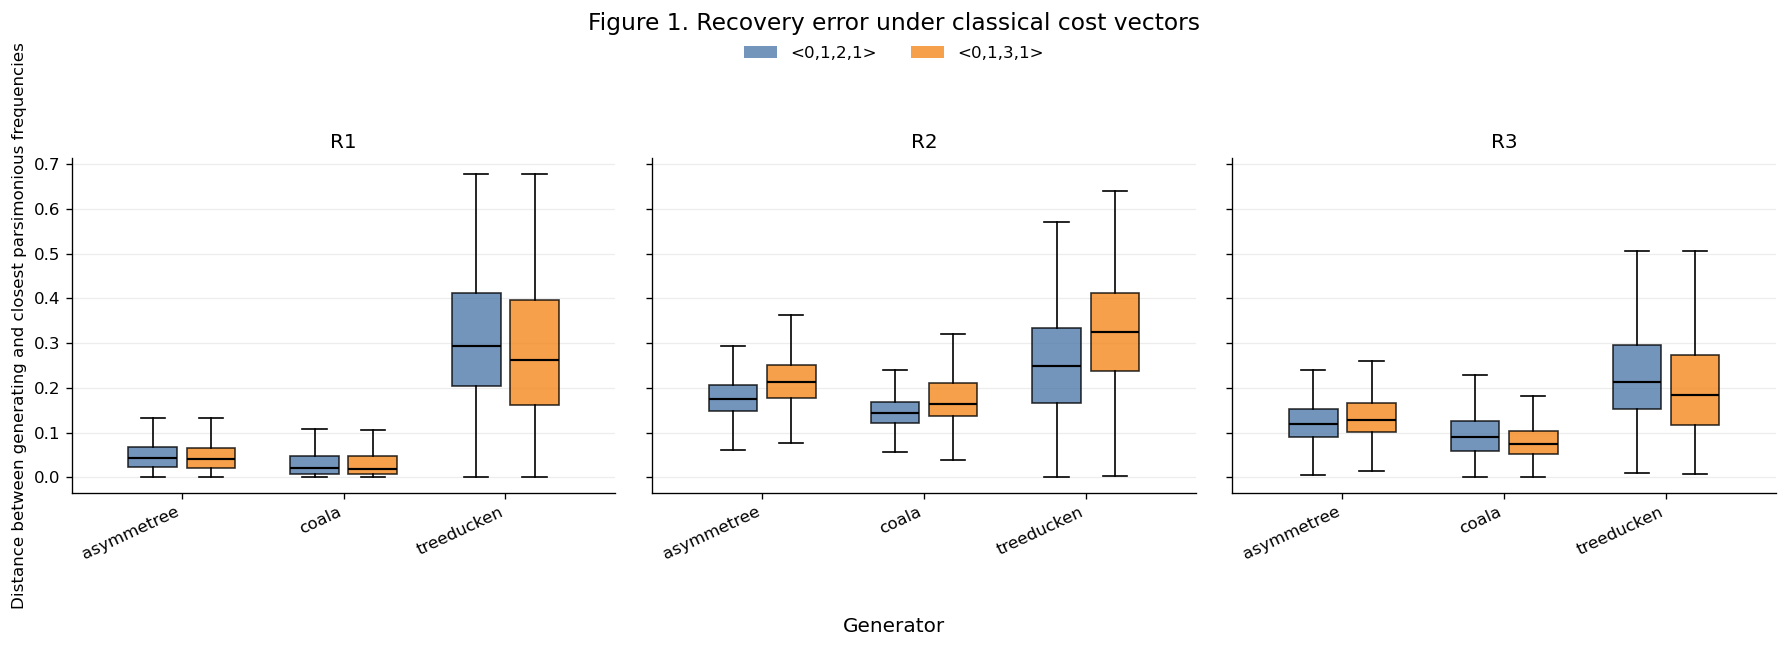

capybara_downstream_outputs/figure1_distance_boxplots.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharey=True)
for ax, region in zip(axes, REGION_ORDER):
    region_data = completed[completed["region"] == region]
    generators = [g for g in GENERATOR_ORDER if (region_data["generator"] == g).any()]
    positions, arrays, colors = [], [], []
    for generator_index, generator in enumerate(generators):
        for offset, cost_label in [(-0.18, "classical_1"), (0.18, "classical_3")]:
            values = region_data.loc[(region_data["generator"] == generator) & (region_data["cost_label"] == cost_label), "min_real_observed_distance"].dropna().to_numpy()
            if len(values):
                positions.append(generator_index + offset); arrays.append(values); colors.append(COST_COLORS[cost_label])
    if arrays:
        boxes = ax.boxplot(arrays, positions=positions, widths=0.30, patch_artist=True, showfliers=False, medianprops={"color": "black", "linewidth": 1.3})
        for patch, color in zip(boxes["boxes"], colors):
            patch.set_facecolor(color); patch.set_alpha(0.78)
    ax.set_xticks(range(len(generators))); ax.set_xticklabels(generators, rotation=25, ha="right")
    ax.set_title(region); ax.grid(axis="y", alpha=0.22)
axes[0].set_ylabel("Distance between generating and closest parsimonious frequencies")
fig.supxlabel("Generator", y=0.02)
fig.suptitle("Figure 1. Recovery error under classical cost vectors", y=1.02, fontsize=14)
fig.legend(handles=[Patch(facecolor=COST_COLORS[c], alpha=.78, label=COST_LABELS[c]) for c in COST_ORDER], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 0.99), frameon=False)
fig.tight_layout(rect=[0, 0.05, 1, 0.92])
figure1_path = OUTPUT_DIR / "figure1_distance_boxplots.png"
fig.savefig(figure1_path, bbox_inches="tight")
plt.show()
print(figure1_path)

## Figure 2 — median generated versus inferred profiles

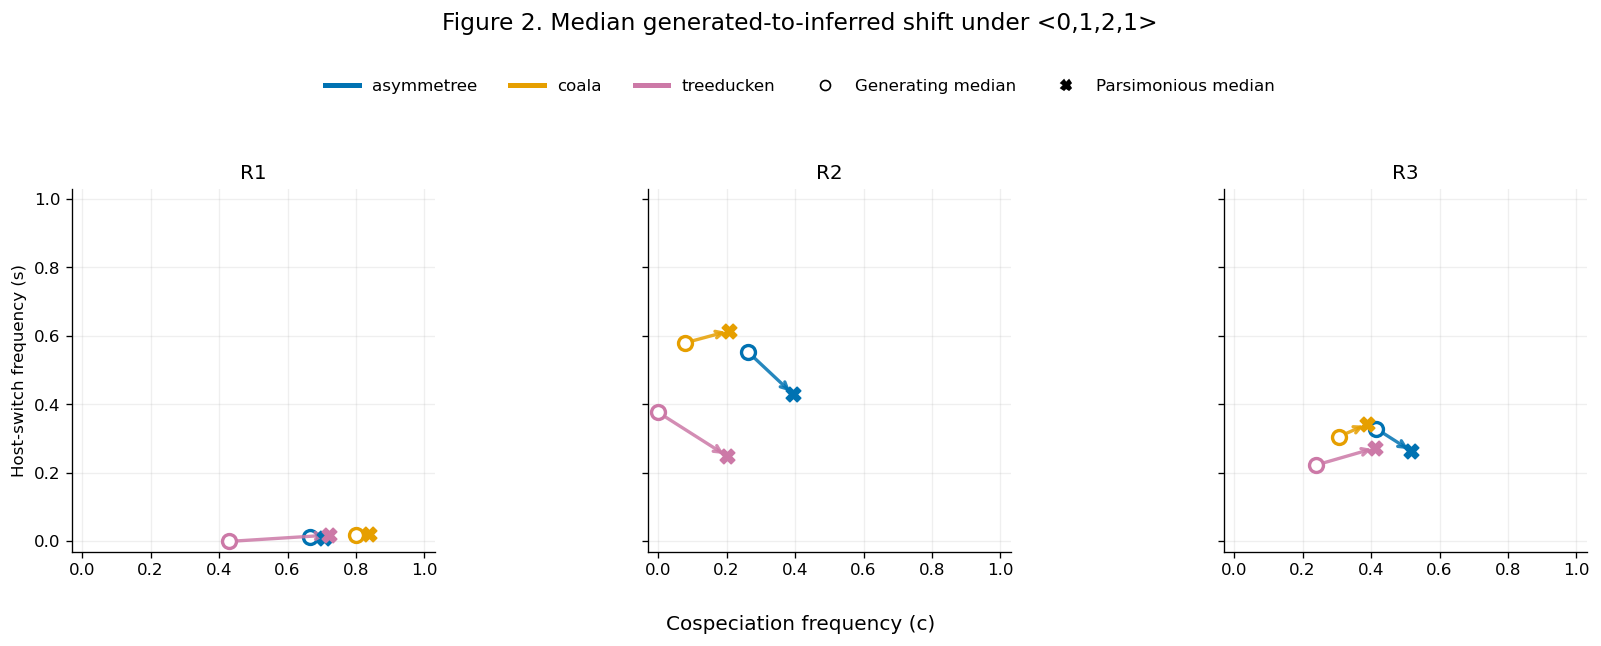

capybara_downstream_outputs/figure2_generated_vs_inferred_profiles.png


In [4]:
profile_data = completed[completed["cost_label"] == "classical_1"].copy()
profiles = profile_data.groupby(["region", "generator"], as_index=False).agg(
    n=("dataset_path", "nunique"), generating_c=("real_cosp_freq", "median"), generating_s=("real_switch_freq", "median"),
    inferred_c=("inferred_cosp_freq", "median"), inferred_s=("inferred_switch_freq", "median"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)
for ax, region in zip(axes, REGION_ORDER):
    for _, row in profiles[profiles["region"] == region].iterrows():
        color = GENERATOR_COLORS.get(row.generator, "#666666")
        ax.annotate("", xy=(row.inferred_c, row.inferred_s), xytext=(row.generating_c, row.generating_s), arrowprops={"arrowstyle": "->", "color": color, "lw": 2, "alpha": .85})
        ax.scatter(row.generating_c, row.generating_s, marker="o", s=70, facecolor="white", edgecolor=color, linewidth=2, zorder=3)
        ax.scatter(row.inferred_c, row.inferred_s, marker="X", s=75, color=color, zorder=4)
    ax.set_title(region); ax.set_xlim(-.03, 1.03); ax.set_ylim(-.03, 1.03); ax.grid(alpha=.2); ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel("Host-switch frequency (s)")
fig.supxlabel("Cospeciation frequency (c)", y=0.02)
generator_handles = [Line2D([0], [0], color=GENERATOR_COLORS[g], lw=3, label=g) for g in GENERATOR_ORDER if g in profiles["generator"].unique()]
point_handles = [Line2D([0], [0], marker="o", markerfacecolor="white", markeredgecolor="black", lw=0, label="Generating median"), Line2D([0], [0], marker="X", color="black", lw=0, label="Parsimonious median")]
fig.legend(handles=generator_handles + point_handles, loc="upper center", ncol=len(generator_handles) + 2, bbox_to_anchor=(.5, 1.01), frameon=False)
fig.suptitle("Figure 2. Median generated-to-inferred shift under <0,1,2,1>", y=1.10, fontsize=14)
fig.tight_layout(rect=[0, .05, 1, .91])
figure2_path = OUTPUT_DIR / "figure2_generated_vs_inferred_profiles.png"
fig.savefig(figure2_path, bbox_inches="tight")
plt.show()
profiles.to_csv(OUTPUT_DIR / "generated_vs_inferred_medians.csv", index=False)
print(figure2_path)

## Supplementary figures — directional bias and solution-space ambiguity

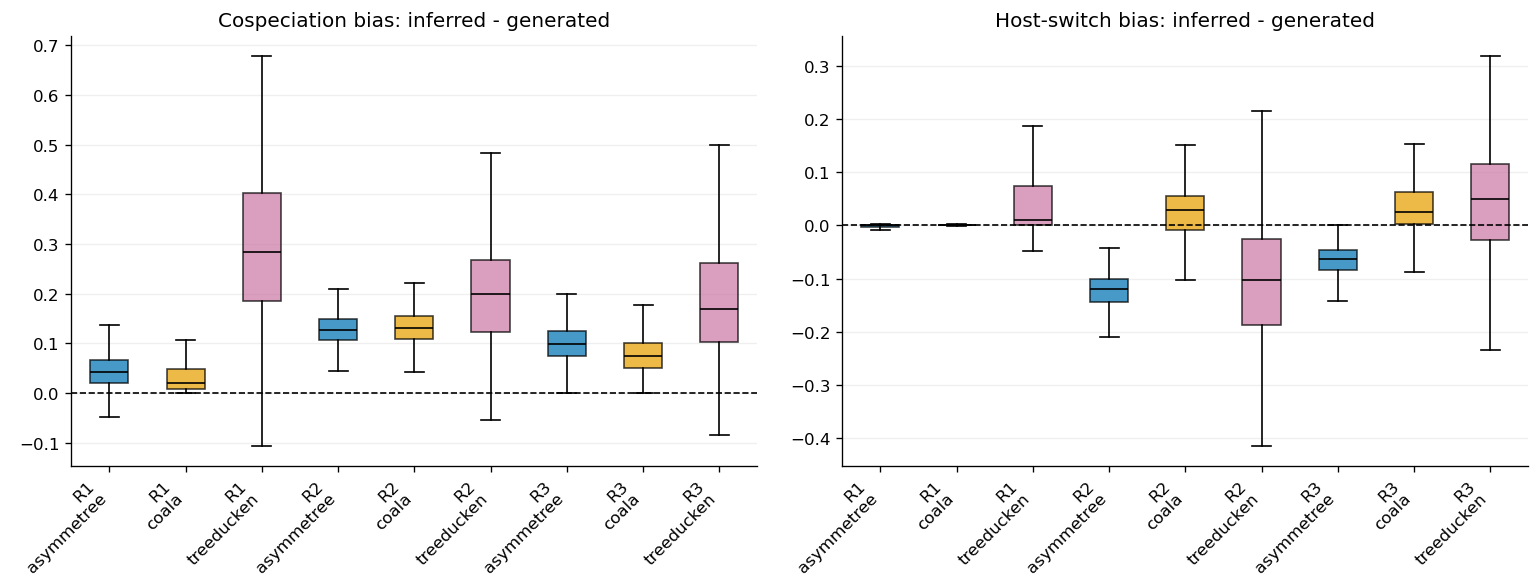

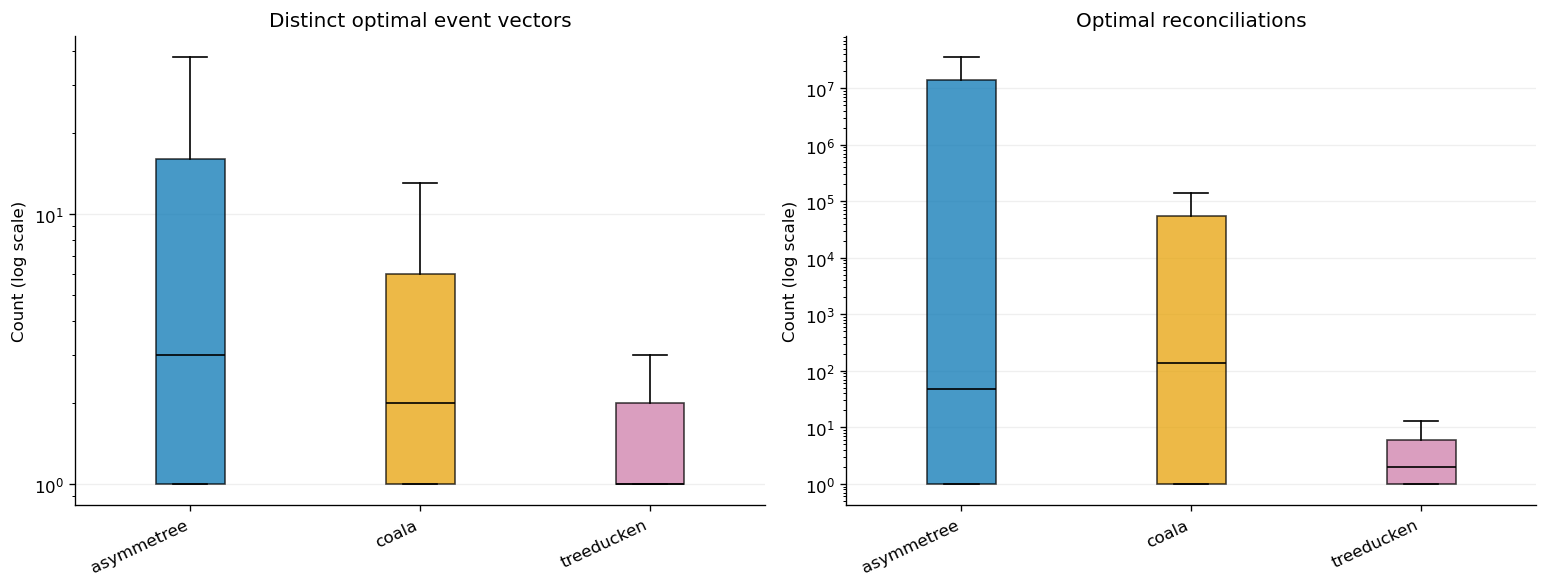

In [5]:
bias_data = completed[completed["cost_label"] == "classical_1"].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for ax, column, title in zip(axes, ["delta_cosp", "delta_switch"], ["Cospeciation bias: inferred - generated", "Host-switch bias: inferred - generated"]):
    labels, arrays, colors = [], [], []
    for region in REGION_ORDER:
        for generator in GENERATOR_ORDER:
            values = bias_data.loc[(bias_data["region"] == region) & (bias_data["generator"] == generator), column].dropna().to_numpy()
            if len(values):
                labels.append(f"{region}\n{generator}"); arrays.append(values); colors.append(GENERATOR_COLORS.get(generator, "#777777"))
    boxes = ax.boxplot(arrays, patch_artist=True, showfliers=False, medianprops={"color": "black"})
    for patch, color in zip(boxes["boxes"], colors): patch.set_facecolor(color); patch.set_alpha(.72)
    ax.axhline(0, color="black", lw=1, ls="--"); ax.set_xticks(range(1, len(labels)+1)); ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_title(title); ax.grid(axis="y", alpha=.2)
fig.tight_layout()
bias_path = OUTPUT_DIR / "supplementary_directional_bias.png"
fig.savefig(bias_path, bbox_inches="tight")
plt.show()

ambiguity = completed.copy()
ambiguity["optimal_count_numeric"] = pd.to_numeric(ambiguity["optimal_count"], errors="coerce")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, column, title in zip(axes, ["event_vector_count", "optimal_count_numeric"], ["Distinct optimal event vectors", "Optimal reconciliations"]):
    labels, arrays, colors = [], [], []
    for generator in GENERATOR_ORDER:
        values = ambiguity.loc[ambiguity["generator"] == generator, column].dropna().to_numpy(dtype=float)
        values = values[values > 0]
        if len(values): labels.append(generator); arrays.append(values); colors.append(GENERATOR_COLORS.get(generator, "#777777"))
    boxes = ax.boxplot(arrays, patch_artist=True, showfliers=False, medianprops={"color": "black"})
    for patch, color in zip(boxes["boxes"], colors): patch.set_facecolor(color); patch.set_alpha(.72)
    ax.set_yscale("log"); ax.set_xticks(range(1, len(labels)+1)); ax.set_xticklabels(labels, rotation=25, ha="right"); ax.set_title(title); ax.set_ylabel("Count (log scale)"); ax.grid(axis="y", alpha=.2)
fig.tight_layout()
ambiguity_path = OUTPUT_DIR / "supplementary_solution_space_ambiguity.png"
fig.savefig(ambiguity_path, bbox_inches="tight")
plt.show()

## Summary tables and processing accounting

In [6]:
def q25(series): return series.quantile(.25)
def q75(series): return series.quantile(.75)

results_summary = completed.groupby(["region", "regime", "generator", "cost_label"], as_index=False).agg(
    successful_datasets=("dataset_path", "nunique"), median_distance=("min_real_observed_distance", "median"),
    distance_q25=("min_real_observed_distance", q25), distance_q75=("min_real_observed_distance", q75),
    median_delta_cosp=("delta_cosp", "median"), median_delta_switch=("delta_switch", "median"),
    median_event_vector_count=("event_vector_count", "median"), median_elapsed_seconds=("task_elapsed_seconds", "median"))
results_summary["cost_vector"] = results_summary["cost_label"].map(COST_LABELS)

def classify_status(row):
    status = str(row.get("capybara_status", "")).lower()
    reason = str(row.get("skip_reason", "")).lower()
    if "timeout" in status or "timeout" in reason: return "timeout"
    if status == "completed" and pd.notna(row.get("min_real_observed_distance")): return "successful"
    return "error_or_skipped"

classical["processing_outcome"] = classical.apply(classify_status, axis=1)
workbook_outcomes = classical[["dataset_path", "region", "regime", "generator", "cost_label", "processing_outcome"]].copy()

# Timeouts and setup failures are recorded separately by the experiment notebook.
ERROR_LEDGER = REPO_ROOT / "capybara_checkpoints" / "setup_errors.csv"
if ERROR_LEDGER.exists():
    error_ledger = pd.read_csv(ERROR_LEDGER)
    error_ledger["generator"] = error_ledger["generator"].astype(str).str.lower()
    error_ledger["regime"] = error_ledger["regime"].astype(str).str.lower()
    error_ledger["region"] = error_ledger["regime"].map(REGIME_TO_REGION)
    error_ledger["processing_outcome"] = np.where(error_ledger["error_type"].astype(str).str.lower().eq("timeout"), "timeout", "error_or_skipped")
    ledger_outcomes = error_ledger[["dataset_path", "region", "regime", "generator", "cost_label", "processing_outcome"]].copy()
    # Setup failures occur before a cost task exists, so retain them with a setup label.
    ledger_outcomes["cost_label"] = ledger_outcomes["cost_label"].fillna("setup_validation")
else:
    error_ledger = pd.DataFrame()
    ledger_outcomes = pd.DataFrame(columns=workbook_outcomes.columns)

all_outcomes = pd.concat([workbook_outcomes, ledger_outcomes], ignore_index=True)
task_counts = all_outcomes.groupby(["region", "regime", "generator", "cost_label", "processing_outcome"], dropna=False).size().unstack(fill_value=0).reset_index()
for column in ["successful", "error_or_skipped", "timeout"]:
    if column not in task_counts: task_counts[column] = 0
task_counts["total_tasks"] = task_counts[["successful", "error_or_skipped", "timeout"]].sum(axis=1)

# Dataset availability for every generator/regime. A dataset is fully successful
# only when all of its recorded classical-cost tasks completed successfully.
group_dataset_outcomes = all_outcomes.groupby(
    ["dataset_path", "region", "regime", "generator"], dropna=False
)["processing_outcome"].agg(list).reset_index()
group_dataset_outcomes["dataset_outcome"] = group_dataset_outcomes["processing_outcome"].apply(
    lambda values: "fully_successful" if all(value == "successful" for value in values)
    else ("timeout" if "timeout" in values else "error_or_skipped")
)
availability_by_group = group_dataset_outcomes.groupby(
    ["region", "regime", "generator", "dataset_outcome"], dropna=False
).size().unstack(fill_value=0).reset_index()
for column in ["fully_successful", "error_or_skipped", "timeout"]:
    if column not in availability_by_group:
        availability_by_group[column] = 0
availability_by_group = availability_by_group.rename(columns={
    "fully_successful": "fully_successful_datasets",
    "error_or_skipped": "datasets_with_error",
    "timeout": "datasets_with_timeout",
})
availability_by_group["datasets_considered"] = availability_by_group[[
    "fully_successful_datasets", "datasets_with_error", "datasets_with_timeout"
]].sum(axis=1)
availability_by_group["fully_successful_percentage"] = (
    100 * availability_by_group["fully_successful_datasets"]
    / availability_by_group["datasets_considered"]
)
availability_by_group = availability_by_group.sort_values(
    ["region", "regime", "generator"]
).reset_index(drop=True)

# Add these availability counts to every matching cost-vector result row.
results_summary = results_summary.merge(
    availability_by_group, on=["region", "regime", "generator"], how="left"
)

dataset_outcomes = all_outcomes.groupby("dataset_path")["processing_outcome"].agg(list).reset_index()
dataset_outcomes["dataset_outcome"] = dataset_outcomes["processing_outcome"].apply(lambda values: "fully_successful" if all(v == "successful" for v in values) else ("timeout" if "timeout" in values else "error_or_skipped"))
dataset_counts = dataset_outcomes["dataset_outcome"].value_counts().rename_axis("dataset_outcome").reset_index(name="datasets")
overall_processing = pd.DataFrame([{
    "successful_tasks": int((all_outcomes["processing_outcome"] == "successful").sum()),
    "error_or_skipped_records": int((all_outcomes["processing_outcome"] == "error_or_skipped").sum()),
    "timeout_tasks": int((all_outcomes["processing_outcome"] == "timeout").sum()),
    "unique_datasets_seen": int(all_outcomes["dataset_path"].nunique()),
    "fully_successful_datasets": int((dataset_outcomes["dataset_outcome"] == "fully_successful").sum()),
    "datasets_with_error": int((dataset_outcomes["dataset_outcome"] == "error_or_skipped").sum()),
    "datasets_with_timeout": int((dataset_outcomes["dataset_outcome"] == "timeout").sum()),
}])

results_summary.to_csv(OUTPUT_DIR / "results_summary.csv", index=False)
availability_by_group.to_csv(OUTPUT_DIR / "dataset_availability_by_generator_regime.csv", index=False)
task_counts.to_csv(OUTPUT_DIR / "processing_counts_by_group.csv", index=False)
dataset_counts.to_csv(OUTPUT_DIR / "dataset_processing_counts.csv", index=False)
overall_processing.to_csv(OUTPUT_DIR / "overall_processing_counts.csv", index=False)
with pd.ExcelWriter(OUTPUT_DIR / "capybara_downstream_tables.xlsx", engine="openpyxl") as writer:
    results_summary.to_excel(writer, sheet_name="results_summary", index=False)
    availability_by_group.to_excel(writer, sheet_name="dataset_availability", index=False)
    task_counts.to_excel(writer, sheet_name="processing_by_group", index=False)
    dataset_counts.to_excel(writer, sheet_name="dataset_counts", index=False)
    overall_processing.to_excel(writer, sheet_name="overall_processing", index=False)
    profiles.to_excel(writer, sheet_name="profile_medians", index=False)

display(results_summary)
display(availability_by_group)
display(task_counts)
display(dataset_counts)
display(overall_processing)

,region,regime,generator,cost_label,successful_datasets,median_distance,distance_q25,distance_q75,median_delta_cosp,median_delta_switch,median_event_vector_count,median_elapsed_seconds,cost_vector,datasets_with_error,fully_successful_datasets,datasets_with_timeout,datasets_considered,fully_successful_percentage
0,R1,high_cosp,coala,classical_1,999,0.021024,0.007895,0.048225,0.020822,0.000303,1.0,0.868724,"<0,1,2,1>",0,999,0,999,100.000000
1,R1,high_cosp,coala,classical_3,999,0.019511,0.007909,0.047310,0.018158,0.000204,1.0,0.860308,"<0,1,3,1>",0,999,0,999,100.000000
2,R1,high_cosp,treeducken,classical_1,990,0.293784,0.205120,0.412605,0.283277,0.010784,1.0,0.023146,"<0,1,2,1>",0,990,0,990,100.000000
3,R1,high_cosp,treeducken,classical_3,990,0.261391,0.161509,0.395501,0.255483,0.000000,1.0,0.026381,"<0,1,3,1>",0,990,0,990,100.000000
4,R1,low_switch,asymmetree,classical_1,1000,0.043987,0.022845,0.067482,0.042877,0.000000,1.0,0.940602,"<0,1,2,1>",0,1000,0,1000,100.000000
5,R1,low_switch,asymmetree,classical_3,1000,0.041901,0.021869,0.066361,0.040633,-0.000917,1.0,0.956522,"<0,1,3,1>",0,1000,0,1000,100.000000
6,R2,high_switch,asymmetree,classical_1,662,0.174453,0.147253,0.205657,0.125984,-0.120146,76.0,9.147632,"<0,1,2,1>",0,657,343,1000,65.700000
7,R2,high_switch,asymmetree,classical_3,757,0.212433,0.177567,0.251689,0.119150,-0.173356,49.0,8.815026,"<0,1,3,1>",0,657,343,1000,65.700000
8,R2,high_switch,coala,classical_1,999,0.143113,0.121316,0.169527,0.130684,0.029108,6.0,0.984265,"<0,1,2,1>",0,999,0,999,100.000000
9,R2,high_switch,coala,classical_3,999,0.164346,0.136326,0.210024,0.147707,-0.054842,4.0,0.926096,"<0,1,3,1>",0,999,0,999,100.000000


dataset_outcome,region,regime,generator,datasets_with_error,fully_successful_datasets,datasets_with_timeout,datasets_considered,fully_successful_percentage
0,R1,high_cosp,coala,0,999,0,999,100.000000
1,R1,high_cosp,cophylo,286,0,0,286,0.000000
2,R1,high_cosp,treeducken,0,990,0,990,100.000000
3,R1,low_switch,asymmetree,0,1000,0,1000,100.000000
4,R2,high_switch,asymmetree,0,657,343,1000,65.700000
5,R2,high_switch,coala,0,999,0,999,100.000000
6,R2,high_switch,cophylo,60,0,0,60,0.000000
7,R2,high_switch,treeducken,0,854,0,854,100.000000
8,R3,medium,asymmetree,0,998,2,1000,99.800000
9,R3,medium,coala,0,999,0,999,100.000000


processing_outcome,region,regime,generator,cost_label,error_or_skipped,successful,timeout,total_tasks
0,R1,high_cosp,coala,classical_1,0,999,0,999
1,R1,high_cosp,coala,classical_3,0,999,0,999
2,R1,high_cosp,cophylo,setup_validation,286,0,0,286
3,R1,high_cosp,treeducken,classical_1,0,990,0,990
4,R1,high_cosp,treeducken,classical_3,0,990,0,990
5,R1,low_switch,asymmetree,classical_1,0,1000,0,1000
6,R1,low_switch,asymmetree,classical_3,0,1000,0,1000
7,R2,high_switch,asymmetree,classical_1,338,662,338,1338
8,R2,high_switch,asymmetree,classical_3,243,757,243,1243
9,R2,high_switch,asymmetree,transformed,0,0,53,53


,dataset_outcome,datasets
0,fully_successful,8473
1,error_or_skipped,454
2,timeout,346


,successful_tasks,error_or_skipped_records,timeout_tasks,unique_datasets_seen,fully_successful_datasets,datasets_with_error,datasets_with_timeout
0,17055,1037,639,9273,8473,454,346


## Output inventory

In [7]:
for path in sorted(OUTPUT_DIR.iterdir()):
    print(path)

capybara_downstream_outputs/capybara_downstream_tables.xlsx
capybara_downstream_outputs/dataset_availability_by_generator_regime.csv
capybara_downstream_outputs/dataset_processing_counts.csv
capybara_downstream_outputs/figure1_distance_boxplots.png
capybara_downstream_outputs/figure2_generated_vs_inferred_profiles.png
capybara_downstream_outputs/generated_vs_inferred_medians.csv
capybara_downstream_outputs/overall_processing_counts.csv
capybara_downstream_outputs/processing_counts_by_group.csv
capybara_downstream_outputs/results_summary.csv
capybara_downstream_outputs/supplementary_directional_bias.png
capybara_downstream_outputs/supplementary_solution_space_ambiguity.png
